# 📝 Instrucciones: Análisis de Sentimientos con Naive Bayes

Los modelos **Naive Bayes** son muy útiles cuando queremos analizar sentimientos, clasificar textos en tópicos o recomendaciones, ya que las características de estos desafíos cumplen muy bien con los supuestos teóricos y metodológicos del modelo.

En este proyecto practicarás con un conjunto de datos para crear un clasificador de reseñas de la tienda de Google Play.

---

## Paso 1: Carga del conjunto de datos

El conjunto de datos se encuentra en el siguiente enlace. Puedes cargarlo directamente o descargarlo:

* **URL:** [playstore_reviews.csv](https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv)

### Variables del Dataset:
* `package_name`: Nombre de la aplicación móvil (categórico).
* `review`: Comentario sobre la aplicación móvil (categórico).
* `polarity`: Variable de clase (0 o 1), siendo **0 negativo** y **1 positivo** (categórico numérico).

---

## Paso 2: Estudio de variables y su contenido

En este caso, tenemos solo 3 variables. Realmente solo nos interesa la parte del comentario (`review`), ya que la clasificación dependerá de su contenido y no del nombre del paquete. Por lo tanto, la variable `package_name` debe ser eliminada.

### Procesamiento de Texto
Antes de entrenar, debemos procesar el texto plano:

1.  **Limpieza:** Eliminar espacios y convertir a minúsculas.
    ```python
    df["column"] = df["column"].str.strip().str.lower()
    ```
2.  **División de datos:** Separar en `X_train`, `X_test`, `y_train`, `y_test`.
3.  **Vectorización:** Transformar el texto en una matriz de recuento de palabras usando `CountVectorizer`.
    ```python
    vec_model = CountVectorizer(stop_words = "english")
    X_train = vec_model.fit_transform(X_train).toarray()
    X_test = vec_model.transform(X_test).toarray()
    ```

---

## Paso 3: Construye un Naive Bayes

Implementa el modelo eligiendo entre las tres variantes principales según lo estudiado:
* `GaussianNB`
* `MultinomialNB`
* `BernoulliNB`

**Tarea:** Entrena las tres implementaciones y compara cuál es la más adecuada para este tipo de datos (conteo de palabras).

---

## Paso 4: Optimiza el modelo anterior

Tras elegir la mejor variante de Naive Bayes, intenta comparar u optimizar los resultados utilizando un **Random Forest** para ver si mejora la precisión.

---

## Paso 5: Guarda el modelo

Almacena el modelo entrenado en la carpeta correspondiente de tu proyecto (por ejemplo, usando `pickle` o `joblib`).

---

## Paso 6: Explora otras alternativas

¿Qué otros modelos de los que hemos estudiado podrías utilizar para intentar superar los resultados de un Naive Bayes? 
* **Argumenta tu respuesta.**
* **Entrena el modelo elegido.**

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from lightgbm import LGBMClassifier
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold)
from sklearn.metrics import ( confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve)
from scipy.stats import randint, loguniform
from sklearn.feature_extraction.text import CountVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.model_selection import cross_val_score

In [2]:
# Cargamos el dataset de playstore_reviews
df=pd.read_csv("../data/raw/playstore_reviews.csv")
df.head(3)

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0


In [3]:
#chekamos la info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB


In [4]:
#Obtenemos que columnas tienen valores unicos y su porcentage respectivamente
print("------------------PORCENTAJE DE VALORES UNICOS DEL df---------------------\n")
info_uniques = pd.DataFrame({
    'Valores Únicos': df.nunique(),
    'Total Filas': len(df),
    '% Unicidad': (df.nunique() / len(df)) * 100
}).sort_values(by = '% Unicidad', ascending = False)
info_uniques

------------------PORCENTAJE DE VALORES UNICOS DEL df---------------------



,Valores Únicos,Total Filas,% Unicidad
review,891,891,100.000000
package_name,23,891,2.581369
polarity,2,891,0.224467


## Analisis Hasta Ahora:
* Tenemos un dataframe de datos de reviews con 891 filasy 3 columnas.
* 2 Columnas son STR y 1 INT.
* `polarity` es nustro target que son valores 0 o 1.
* `package_name` no aporta info relevante hay que eliminarla.

In [5]:
# Eliminamos package_name
df.drop(["package_name"],  axis = 1,  inplace = True)
df

,review,polarity
0,privacy at least put some option appear offli...,0
1,"messenger issues ever since the last update, ...",0
2,profile any time my wife or anybody has more ...,0
3,the new features suck for those of us who don...,0
4,forced reload on uploading pic on replying co...,0
...,...,...
886,loved it i loooooooooooooovvved it because it...,1
887,all time legendary game the birthday party le...,1
888,ads are way to heavy listen to the bad review...,0
889,fun works perfectly well. ads aren't as annoy...,1


In [6]:
# Luego eiminamos espacios antes y despues de las reviews(esto no quita los que hay entre palabras), ademas pasamos todo a minusculas
df["review"] = df["review"].str.strip().str.lower()
df

,review,polarity
0,privacy at least put some option appear offlin...,0
1,"messenger issues ever since the last update, i...",0
2,profile any time my wife or anybody has more t...,0
3,the new features suck for those of us who don'...,0
4,forced reload on uploading pic on replying com...,0
...,...,...
886,loved it i loooooooooooooovvved it because it ...,1
887,all time legendary game the birthday party lev...,1
888,ads are way to heavy listen to the bad reviews...,0
889,fun works perfectly well. ads aren't as annoyi...,1


In [7]:
#Separamos nuestro target
X = df.drop('polarity',axis=1)
y = df['polarity']

In [8]:
#Vemos que tan equilibradas estan las clases
y.value_counts()

polarity
0    584
1    307
Name: count, dtype: int64

In [9]:
# Aplicamos un oversampling a tener un dataset con pocas filas priorizando la clase 1
ros = RandomOverSampler(sampling_strategy = "minority", random_state = 42)
X_over, y_over = ros.fit_resample(X, y)

In [10]:
#Luego hacemos un split 67%-33%
X_train, X_test, y_train, y_test = train_test_split(X_over, y_over, test_size = 0.33, random_state = 42)
X_train

,review
526,seriously needs usability updates. app is ok b...
998,improve tapai ko app dheri ramro ra upayogi xa...
137,i love playing candy crush but... why when u g...
1129,very useful i haven't used it as much as i cou...
676,very good apps ŕ¤§ŕľŕ¤°ŕľ ŕ¤°ŕ¤žŕ¤žŕľŕ¤°ŕľ...
...,...
1044,it's all awesome. can you devs please add more...
1095,update few things.... uc mini is very speed fo...
1130,awesome
860,great little game. this is a great little game...


In [11]:
# Siguiendo las instrucciones del enunciado use CountVectorizer pero este me arrojaba: "array[[[1]]]"
# Por lo que invertigando vi que tenia que pasar el pandas data frame a str antes de llevarlo al CountVectorizer
X_train = X_train["review"].astype(str) 
X_test = X_test['review'].astype(str)
# Ahora si
vec_model = CountVectorizer(stop_words = "english")
X_train = vec_model.fit_transform(X_train).toarray()
X_test = vec_model.transform(X_test).toarray()
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(782, 3010))

## Que hacemos ahora?:
Tenemos ahora un array de 3010 columnas, y 782 filas Vamos a proceder a aplicar los tres modelos estudiados en clases:
* `GaussianNB`
* `MultinomialNB`
* `BernoulliNB`

In [12]:
#Primero vamos con GaussianNB que en escencia sigue la misma estructura de uso que los anteriores que hemos trabajado, si de codigo hablamos.
model_GNB = GaussianNB()
model_GNB.fit(X_train, y_train)

predict_GNB = model_GNB.predict(X_test)
metrics_GNB = classification_report(y_test, predict_GNB, output_dict = True)
print(classification_report(y_test, predict_GNB))

              precision    recall  f1-score   support

           0       0.91      0.77      0.83       209
           1       0.77      0.91      0.83       177

    accuracy                           0.83       386
   macro avg       0.84      0.84      0.83       386
weighted avg       0.84      0.83      0.83       386



In [13]:
#Ahora el MultinomialNB
model_MNB = MultinomialNB()
model_MNB.fit(X_train, y_train)
predict_MNB = model_MNB.predict(X_test)
metrics_MNB = classification_report(y_test, predict_MNB, output_dict = True)
print(classification_report(y_test, predict_MNB))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       209
           1       0.83      0.92      0.87       177

    accuracy                           0.88       386
   macro avg       0.88      0.88      0.88       386
weighted avg       0.88      0.88      0.88       386



In [14]:
# Y el BernoulliNB
model_BNB = BernoulliNB()

model_BNB.fit(X_train, y_train)

predict_BNB = model_BNB.predict(X_test)
metrics_BNB = classification_report(y_test, predict_BNB, output_dict = True)
print(classification_report(y_test, predict_BNB))

              precision    recall  f1-score   support

           0       0.93      0.76      0.84       209
           1       0.76      0.94      0.84       177

    accuracy                           0.84       386
   macro avg       0.85      0.85      0.84       386
weighted avg       0.86      0.84      0.84       386



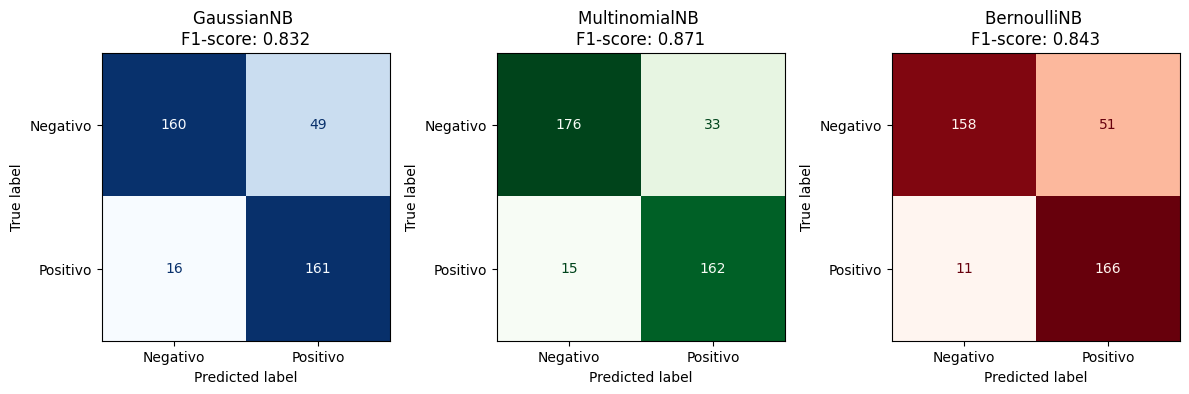

In [15]:
# Vamos ahora a comparar las 3 predicciones con una matriz de confucion
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# GaussianNB 
cm_GNB = confusion_matrix(y_test, predict_GNB)
disp_GNB = ConfusionMatrixDisplay(confusion_matrix=cm_GNB, display_labels=["Negativo", "Positivo"])
disp_GNB.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"GaussianNB \nF1-score: {metrics_GNB['1']['f1-score']:.3f}")

# MultinomialNB
cm_MNB = confusion_matrix(y_test, predict_MNB)
disp_MNB = ConfusionMatrixDisplay(confusion_matrix=cm_MNB, display_labels=["Negativo", "Positivo"])
disp_MNB.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"MultinomialNB \nF1-score: {metrics_MNB['1']['f1-score']:.3f}")

# BernoulliNB
cm_BNB = confusion_matrix(y_test, predict_BNB)
disp_BNB = ConfusionMatrixDisplay(confusion_matrix=cm_BNB, display_labels=["Negativo", "Positivo"])
disp_BNB.plot(ax=ax3, cmap='Reds', colorbar=False)
ax3.set_title(f"BernoulliNB \nF1-score: {metrics_BNB['1']['f1-score']:.3f}")

plt.tight_layout()
plt.show()

# Analisis de la matriz:
* Las tres tienen un f1-score alto siendo en orden del mejor: MultinomialNB primero, BernoulliNB segundo y GaussianNB tercero.
* Si buscamos presicion en la clase 1: Bernoulli se lleva el premio con solo 11 falsos positivos.
* Si buscamos presicion en la clase 0: Multinomial es el ganador con solo 33 falsos negativos.
* Si buscamos presicion en general: Multinomial tambien es el ganador con un f1-score de 0.871.

* En ejercicios anteriores hemos visto como necesitamos priorizar una clase(casi siempre la 1), pero en este caso no nos especifican nada por lo que buscaremos la mejor prediccion para ambas clases: MultinomialNB con su f1-score de 0.871.

In [16]:
# Ahora hagamos un RandomForest para compararlo con el modelo Multinomial
model_RF = RandomForestClassifier(n_estimators=100, random_state=42)
model_RF.fit(X_train, y_train)
predict_RF = model_RF.predict(X_test)
metrics_RF = classification_report(y_test, predict_RF, output_dict = True)
print(classification_report(y_test, predict_RF))

              precision    recall  f1-score   support

           0       0.94      0.72      0.82       209
           1       0.74      0.95      0.83       177

    accuracy                           0.82       386
   macro avg       0.84      0.83      0.82       386
weighted avg       0.85      0.82      0.82       386



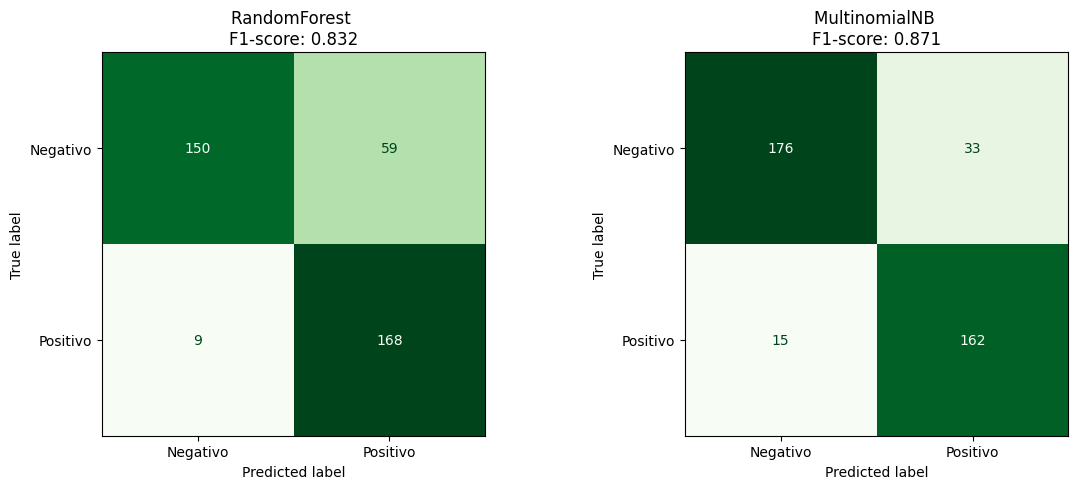

In [17]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# RandomForest
cm_RF = confusion_matrix(y_test, predict_RF)
disp_RF = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels=["Negativo", "Positivo"])
disp_RF.plot(ax=ax1, cmap='Greens', colorbar=False)
ax1.set_title(f"RandomForest \nF1-score: {metrics_RF['1']['f1-score']:.3f}")

# MultinomialNB
cm_MNB = confusion_matrix(y_test, predict_MNB)
disp_MNB = ConfusionMatrixDisplay(confusion_matrix=cm_MNB, display_labels=["Negativo", "Positivo"])
disp_MNB.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"MultinomialNB \nF1-score: {metrics_MNB['1']['f1-score']:.3f}")


plt.tight_layout()
plt.show()

## Analisis RF vs MultinomialNB:


# OJO!!
A partir de aca es el paso 6, que se basa en probar otros modelos, decidi usar el de mi ejercicio anterior "LGBMClassifier" la mayor parte del codigo a continuacion es copiado en su mayoria del mismo ejercicio.

In [18]:
#Vamos a provar distintos parametros usando el RandomForestClassifier
folder = '../data/processed/models/naive_b/'
file = 'model_LGBM.pkl'
path = folder+file
#Si el modelo aun no existe se procede a crear
if not os.path.exists(path):
    os.makedirs(folder)
    cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

    #Aca inicializamos el modelo LGBMClassifier sus parametros son muy similares a otros modelos: objetive="binary" porque que estamos trantando con predicciones de 0 y 1, el n_jobs=-1 para usar todos los nucleos del procesador, etc.
    base_model = LGBMClassifier(objective = "binary", random_state = 42, verbose = -1, n_jobs = -1)

    random_params = {
        # Vamos a aumentar el numero de profuncidad con respecto al ejercicio anterior ya que CountVectorizer genera muchas columnas
        "max_depth": randint(5, 15),
        "learning_rate": loguniform(0.001, 0.2),
        "n_estimators": randint(30, 200),
        "scale_pos_weight": randint(1, 6),
    }
    
    # Contruimos el RandomizedSearchCV le pasamos el modelo, la lista de parametros, el StratifiedKFold, que busque presicsion. 
    # y le decimos que haga 500 repeticiones(que multiplicado por n_splits = 10 del StratifiedKFold serian unas 5000 pruebas)
    random_search = RandomizedSearchCV(
        estimator = base_model,
        param_distributions = random_params,
        n_iter = 500,
        scoring = "precision",
        cv = cv,
        random_state = 42,
        n_jobs = -1,
        verbose = 1
    )
    #Entrenamos y elejimos el mejor modelo
    random_search.fit(X_train, y_train)
    model_LGBM = random_search.best_estimator_
else:
    #Carga el modelo si ya existe asi tarda menos
    model_LGBM = joblib.load(path)


In [19]:
#Imprimimos los resultados
columns = ["max_depth", "learning_rate", "n_estimators", "scale_pos_weight"]
parameters_result = pd.DataFrame([model_LGBM.get_params()])
parameters_result[columns]

,max_depth,learning_rate,n_estimators,scale_pos_weight
0,13,0.085614,177,1


In [20]:
# Luego de hacer obtenido los resultados del RandomizedSearchCV vamos a hacer un GridSearchCV ya con parametros mas especificos
# creamos una funcion range_params que en terminos simples crea un lista tomando como centro el parametro elejido, ejemplo: 6 ---> [4,5,6,7,8] la modifique de mi ejercicio anterior
# para que no me arrojara valores negativos o 0.
def range_params(param, steps = 2, step_size=1, min_val=1):
    param_list = []
    decimals = max(0, -int(round(np.log10(step_size))))
    
    for i in range(steps, 0, -1):
        val = round(param - i*step_size, decimals)
        # Solo agregamos si es mayor al mínimo permitido
        if val >= min_val:
            param_list.append(val)
            
    param_list.append(param)
    
    for i in range(1, steps+1):
        param_list.append(round(param + i*step_size, decimals))
        
    return list(set(param_list))

if not os.path.exists(path):
    #Creamos ahora la lista de parametros de prueba de usando los mejores parametros del RandomizedSearchCV y usando la funciones que creamos "range_params"
    grid_params = {
        "max_depth": range_params(parameters_result["max_depth"][0], 1),
        "learning_rate": range_params(parameters_result["learning_rate"][0], 2, 0.0002),
        "n_estimators": range_params(parameters_result["n_estimators"][0], 2, 2),
        "scale_pos_weight": range_params(parameters_result["scale_pos_weight"][0], 1),
    }

    #Parecido al RandomizedSearchCV contruimos el GridSearchCV
    grid_search = GridSearchCV(
        estimator = base_model,
        param_grid = grid_params,
        scoring = "precision",
        cv = cv,
        n_jobs = -1,
        verbose = 1
    )
    #Lo entrenamos y guardamos
    grid_search.fit(X_train, y_train)
    model_LGBM = grid_search.best_estimator_
    joblib.dump(model_LGBM, path)
else:
    #Carga el modelo si ya existe asi tarda menos
    model_LGBM = joblib.load(path)

In [21]:
#Imprimimos los resultados
columns = ["max_depth", "learning_rate", "n_estimators", "scale_pos_weight"]
parameters_result = pd.DataFrame([model_LGBM.get_params()])
parameters_result[columns]

,max_depth,learning_rate,n_estimators,scale_pos_weight
0,13,0.085614,177,1


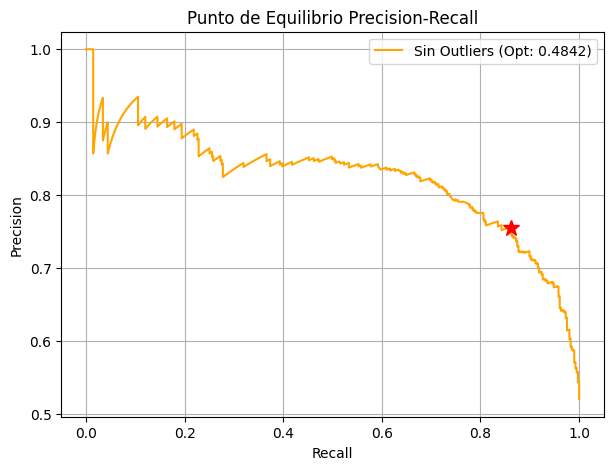

El umbral sugerido es: 0.4842


In [26]:
# Procedemmos a encontrar un umbral optimo usando cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#Creamos un array de ceros del mismo tamaño del set de entrenamiento.
oof_preds = np.zeros(len(X_train))
y_train_array = np.array(y_train)
for train_idx, val_idx in kf.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

    model_LGBM.fit(X_tr, y_tr)
    oof_preds[val_idx] = model_LGBM.predict_proba(X_val)[:, 1]
    

p, r, t = precision_recall_curve(y_train, oof_preds)

f1_scores = 2 * (p * r) / (p + r + 1e-10) 
idx_f1 = np.argmax(f1_scores)

umbral = t[idx_f1]

plt.figure(figsize=(7, 5))
plt.plot(r, p, label = f'Sin Outliers (Opt: {umbral:.4f})', color = 'orange')
plt.plot(r[idx_f1], p[idx_f1], 'r*', markersize = 12) # Estrella en el punto

plt.title('Punto de Equilibrio Precision-Recall')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend(); plt.grid(True); plt.show()
#OJO!! LGBMClassifier lanza ciertas adventencias cuando encuentra cierta distribucion de columnas puestas por CountVectorizer que lo usamos anteriormente
# Esto lo arregla el solo pero aun asi muestra los warnings asi que vamos a silencialos.
warnings.filterwarnings('ignore', category=UserWarning)
print(f"El umbral sugerido es: {umbral:.4f}")

In [23]:
#Vemos los resultados del modelo
model_LGBM.fit(X_train, y_train)
predict_LGBM = model_LGBM.predict_proba(X_test)[:, 1]
predict_LGBM = (predict_LGBM >= umbral).astype(int)
metrics_LGBM = classification_report(y_test, predict_LGBM, output_dict = True)
print(classification_report(y_test, predict_LGBM))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81       209
           1       0.74      0.92      0.82       177

    accuracy                           0.82       386
   macro avg       0.83      0.83      0.82       386
weighted avg       0.84      0.82      0.82       386



## Ahora si
    ya tenemos el modelo LGBMClassifier contruido vamos a compararlo con el MultinomialNB

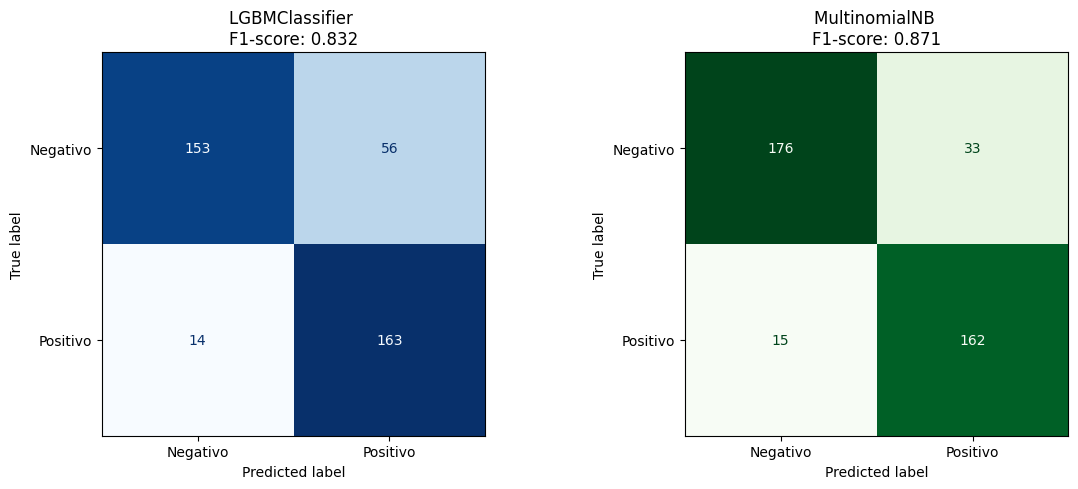

In [24]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# LGBMClassifier
cm_LGBM = confusion_matrix(y_test, predict_LGBM)
disp_LGBM = ConfusionMatrixDisplay(confusion_matrix=cm_LGBM, display_labels=["Negativo", "Positivo"])
disp_LGBM.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"LGBMClassifier \nF1-score: {metrics_RF['1']['f1-score']:.3f}")

# MultinomialNB
cm_MNB = confusion_matrix(y_test, predict_MNB)
disp_MNB = ConfusionMatrixDisplay(confusion_matrix=cm_MNB, display_labels=["Negativo", "Positivo"])
disp_MNB.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"MultinomialNB \nF1-score: {metrics_MNB['1']['f1-score']:.3f}")


plt.tight_layout()
plt.show()

# Conclusiones finales:
El modelo `LGBMClassifier` a pesar de haber llevado optimizacion de parametros sigue siendo inferior con un f1-score de 0.83 vs el modelo `multinomialNB` con un 0.871, esto puede deberse a que el modelo,multinomialNB trabaja mejor con la independencia de las palabras mientras que LightGBM suele hacer overfittig en dataset con muchas columnas(3010 despues de aplicar el CountVectorizer), indiferentemente de esto consiguio un mejor resultado para predicciones de 1 con solo 14 falsos positivos, pero como ya mencionammos con anterioridad al no establecerse un prioridad a una clase u otra nos quedaremos con el que tiene mejor precicion en general que es el `multinomialNB`.

In [25]:
#Guardamos
model_pack = {
    'model_LGBM': model_LGBM,
    'model_GNB': model_GNB,
    'model_RF': model_RF,
    'model_MNB': model_MNB,
    'model_BNB': model_BNB,
    'x_train': X_train,
    'x_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
path = f"../data/processed/models/naive_b/"
if not os.path.exists(path):
    os.makedirs(path)
#  Guardamos el paquete
joblib.dump(model_pack, f'{path}models_pack.pkl')

['../data/processed/models/naive_b/models_pack.pkl']